#### Imports

In [2]:
import os
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


#### Folder Creation & path

In [3]:
notebook_path = os.getcwd()

data_folder = os.path.join(notebook_path, "Data", )
output_folder = os.path.join(notebook_path, "Output")

for folder in [data_folder, output_folder]:
    if not os.path.exists(folder):
        os.mkdir(folder)


#### Data Preparation

In [4]:
df = yf.download("TCS.NS", start="2024-1-1", end="2026-3-1")

# CRITICAL: Yfinance often sets Date as the index. 
# We need it as a column for easier plotting later.
df.reset_index(inplace = True)

File_name = "Stock_data.csv"

df.to_csv(f"Data/{File_name}", index=False)

print(f"{File_name} saved successfully to the data folder!")


[*********************100%***********************]  1 of 1 completed

Stock_data.csv saved successfully to the data folder!


#### Data Cleaning & Sorting

In [5]:
df.shape
print(df.columns)
# Renamed Column Because it has Suffix of .TCS.NS at each header
df.columns = ["Date", "Close", "High", "Low", "Open", "Volume"]
df.info()

print(df.isnull().sum())

df = df.sort_values(by="Date")

df_plot = df.tail(200)


MultiIndex([(  'Date',       ''),
            ( 'Close', 'TCS.NS'),
            (  'High', 'TCS.NS'),
            (   'Low', 'TCS.NS'),
            (  'Open', 'TCS.NS'),
            ('Volume', 'TCS.NS')],
           names=['Price', 'Ticker'])
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536 entries, 0 to 535
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    536 non-null    datetime64[ns]
 1   Close   536 non-null    float64       
 2   High    536 non-null    float64       
 3   Low     536 non-null    float64       
 4   Open    536 non-null    float64       
 5   Volume  536 non-null    int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 25.3 KB
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


#### Data Visualization

Moving Average

In [6]:
df_plot["MA20"] = df_plot["Close"].rolling(window=20).mean()
df_plot["MA50"] = df_plot["Close"].rolling(window=50).mean()

C:\Users\ANIKET-MAI\AppData\Local\Temp\ipykernel_1656\1352522571.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["MA20"] = df_plot["Close"].rolling(window=20).mean()
C:\Users\ANIKET-MAI\AppData\Local\Temp\ipykernel_1656\1352522571.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_plot["MA50"] = df_plot["Close"].rolling(window=50).mean()


#### Matplotlib with Chart Export

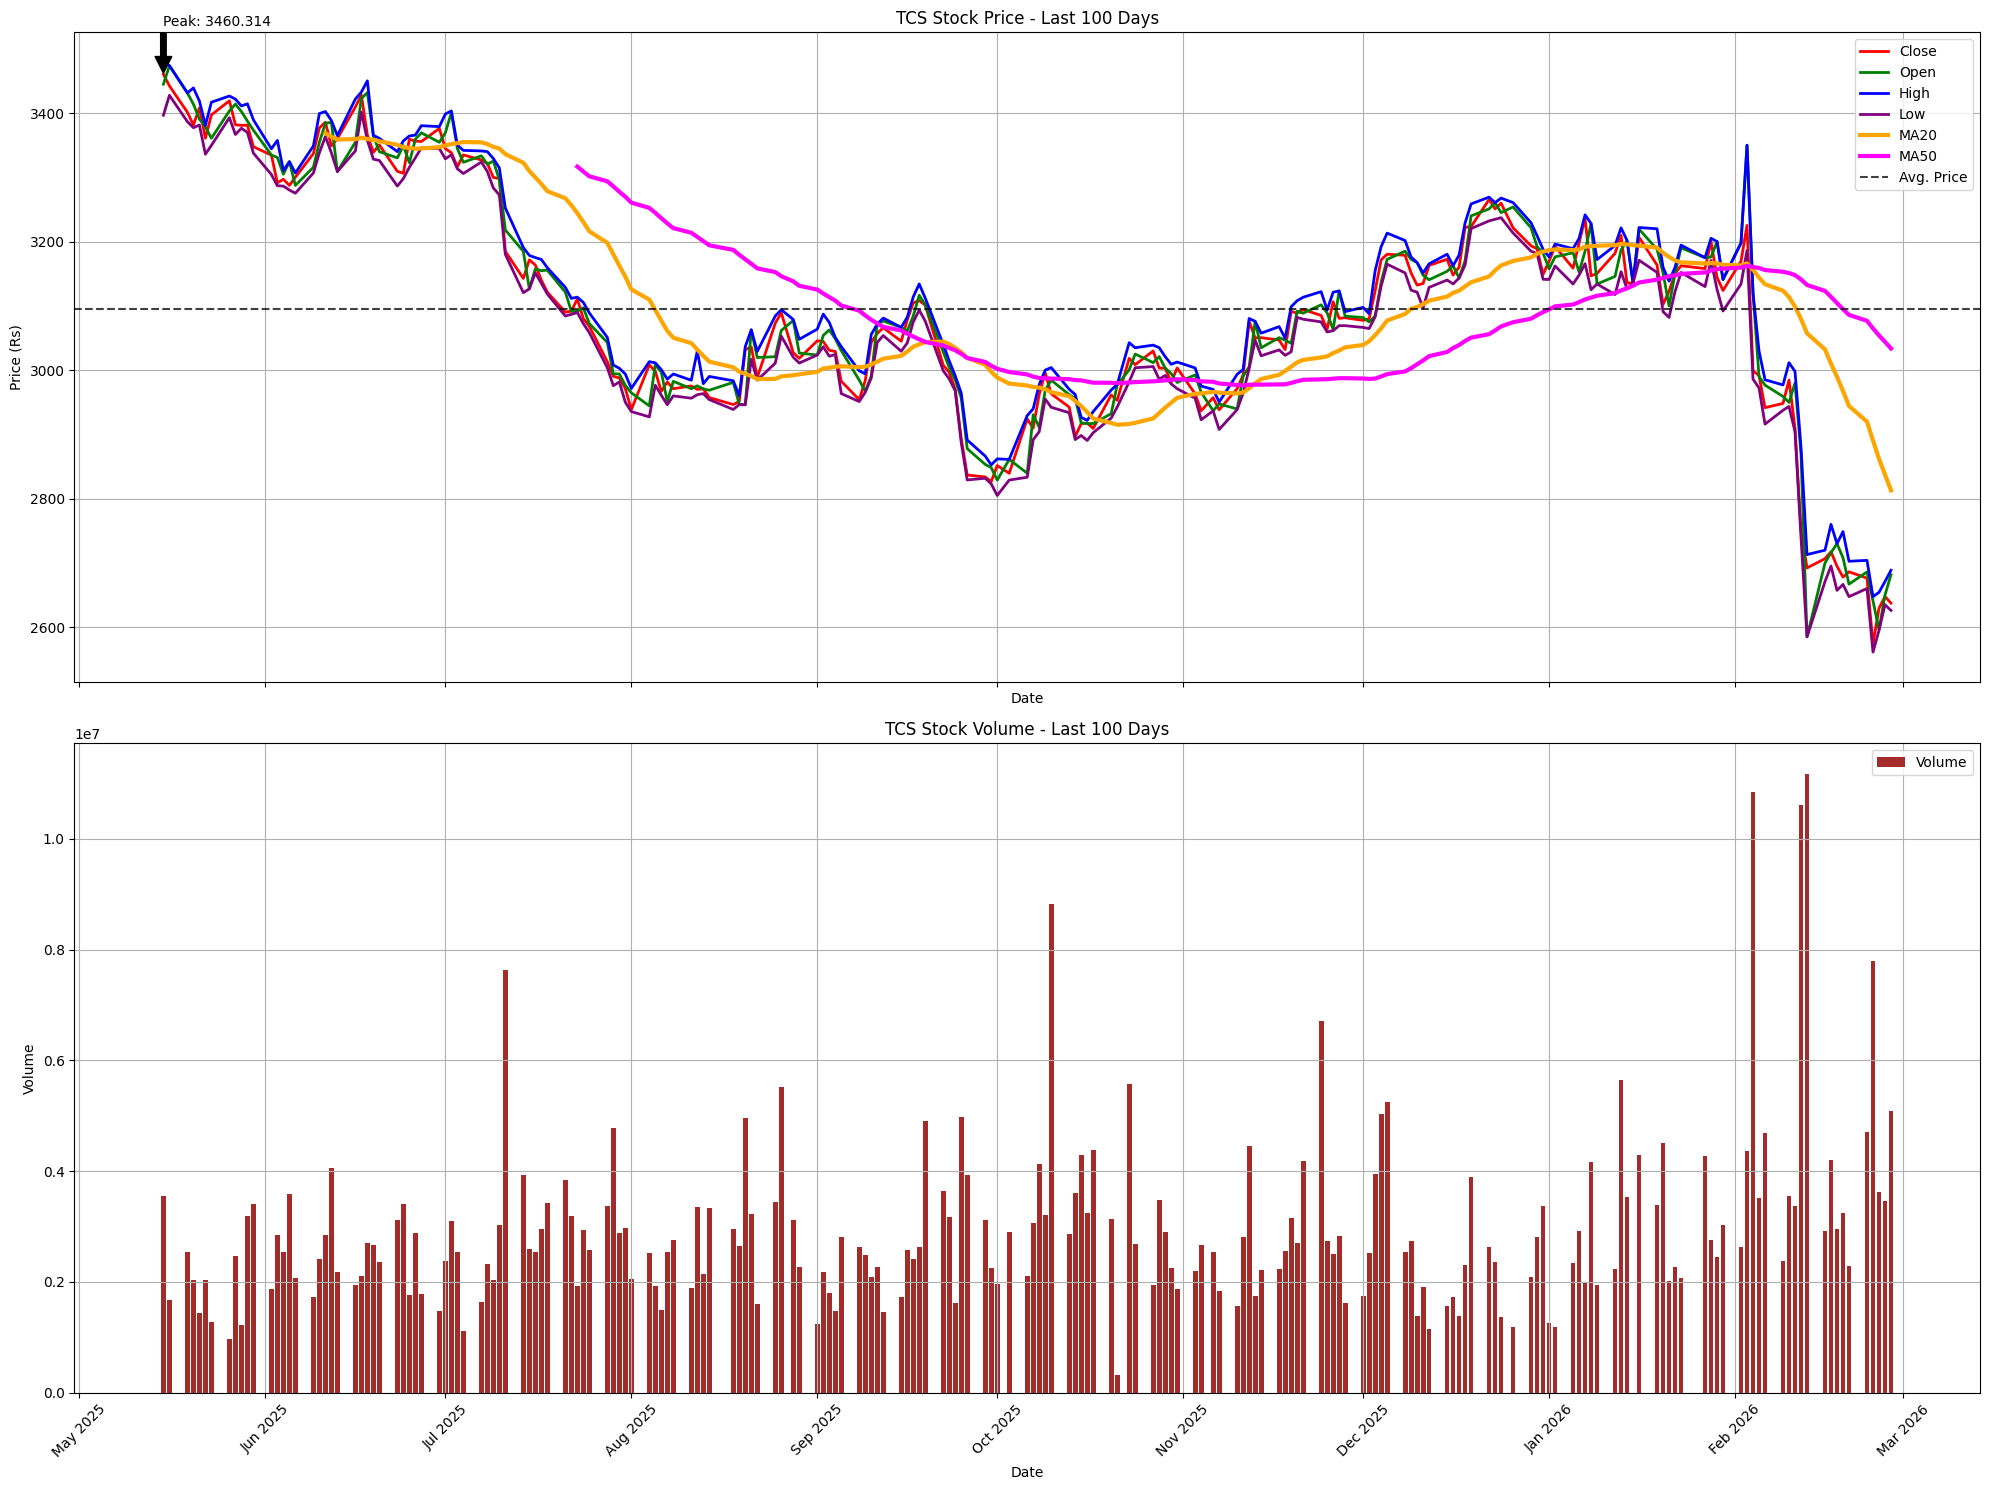

Chart successfully saved to outputs folder!


In [ ]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize = (20,15), sharex=True)


ax1.set_title("TCS Stock Price - Last 100 Days")
ax1.set_ylabel("Price (Rs)")

ax1.plot(df_plot["Date"], df_plot["Close"], label ="Close",color = "red", linewidth = 2)
ax1.plot(df_plot["Date"], df_plot["Open"], label ="Open",color = "green", linewidth = 2)
ax1.plot(df_plot["Date"], df_plot["High"], label ="High",color = "blue", linewidth = 2)
ax1.plot(df_plot["Date"], df_plot["Low"], label ="Low",color = "purple", linewidth = 2)
ax1.plot(df_plot["Date"], df_plot["MA20"], label ="MA20",color = "orange", linewidth = 3)
ax1.plot(df_plot["Date"], df_plot["MA50"], label ="MA50",color = "magenta", linewidth = 3)
max_p = df_plot["Close"].max()
max_d = df_plot.loc[df_plot["Close"].idxmax(), "Date"]

ax1.annotate(f"Peak: {max_p:.3f}",xy=(max_d,max_p),
             xytext=(max_d,max_p+75),arrowprops=dict(facecolor = "black", shrink = 0.025))

ax1.axhline(df_plot["Close"].mean(),  color="black",linestyle = "--", label = "Avg. Price", alpha = 0.75)
ax1.grid(True)
ax1.legend()
# ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
# ax1.tick_params(axis='x', rotation=45)

ax2.set_title("TCS Stock Volume - Last 100 Days")
ax2.bar(df_plot["Date"], df_plot["Volume"], label ="Volume",color = "brown")
ax2.set_xlabel("Date")
ax2.set_ylabel("Volume")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax2.grid(True)
ax2.legend()
ax2.tick_params(axis='x', rotation=45)

# Exporting Chart
plt.tight_layout()
plt.savefig("Output/Stock_Chart.png",dpi=150,bbox_inches='tight')

plt.show()

print("Chart successfully saved to outputs folder!")